In [5]:
import pandas as pd

# === 1. トークンリストを定義 ===
with open("/workspace/clmpy_miyabi/sample/tokens/zinc_normal_tokens.txt") as f:
    TOKENS = [f]

SPECIAL_TOKENS = {"@", "@@"}  

# === 2. 文字列を 1 文字ずつチェックしてトークン化する関数 ===
def tokenize(s):
    tokens = []
    i = 0
    while i < len(s):
        # 2文字トークン "@@" だけ特別扱い
        if s[i:i+2] == "@@":
            tokens.append("@@")
            i += 2
        # 1文字トークン
        elif s[i] in TOKENS:
            tokens.append(s[i])
            i += 1
        else:
            # トークンに該当しない場合は通常の文字列として扱う
            tokens.append(s[i])
            i += 1
    return tokens

# === 3. データを読む ===
for fil in ["251106_GRU_flat1","251106_GRU_flat2","251106_GRU_flat3","251106_GRU_tapering1","251106_GRU_tapering2","251106_GRU_tapering3"] : 
    print(fil)
    df = pd.read_csv(f"/workspace/2510_clmpy_paper/result/{fil}/evaluate_result.csv")

    # === 4. Tokenize ===
    df["answer_tok"] = df["answer"].apply(tokenize)
    df["predict_tok"] = df["predict"].apply(tokenize)

    # === 5. 結果比較 ===
    def compare_tokens(row):
        a, p = row["answer_tok"], row["predict_tok"]
        L = min(len(a), len(p))
        return [(a[i], p[i], a[i] == p[i]) for i in range(L)]

    df["token_compare"] = df.apply(compare_tokens, axis=1)

    # === 6. 集計 ===
    from collections import defaultdict

    correct_count = defaultdict(int)
    total_count = defaultdict(int)

    special_correct = 0
    special_total = 0

    other_correct = 0
    other_total = 0

    for row in df["token_compare"]:
        for a, p, ok in row:
            # 個別トークン集計
            total_count[a] += 1
            if ok:
                correct_count[a] += 1

            # @ と @@ の区分
            if a in SPECIAL_TOKENS:
                special_total += 1
                if ok:
                    special_correct += 1
            else:
                other_total += 1
                if ok:
                    other_correct += 1

    # === 7. トークンごとの DataFrame ===
    result = []
    for tok in sorted(total_count.keys()):
        acc = correct_count[tok] / total_count[tok]
        result.append([tok, total_count[tok], correct_count[tok], acc])

    token_acc_df = pd.DataFrame(result, columns=["token", "total", "correct", "accuracy"])

    # print("=== Token-wise Accuracy ===")
    # print(token_acc_df)

    # === 8. 「@/@@ vs それ以外」比較 ===
    special_acc = special_correct / special_total if special_total > 0 else 0
    other_acc = other_correct / other_total if other_total > 0 else 0

    summary_df = pd.DataFrame([
        ["@ / @@", special_total, special_correct, special_acc],
        ["others", other_total, other_correct, other_acc]
    ], columns=["group", "total", "correct", "accuracy"])

    print("\n=== Group Comparison: @/@@ vs Others ===")
    print(summary_df)


251106_GRU_flat1

=== Group Comparison: @/@@ vs Others ===
    group    total  correct  accuracy
0  @ / @@   192429   169837  0.882596
1  others  5048645  4447257  0.880881
251106_GRU_flat2

=== Group Comparison: @/@@ vs Others ===
    group    total  correct  accuracy
0  @ / @@   192673   175480  0.910766
1  others  5051743  4738360  0.937965
251106_GRU_flat3

=== Group Comparison: @/@@ vs Others ===
    group    total  correct  accuracy
0  @ / @@   192539   171626  0.891383
1  others  5049128  4683078  0.927502
251106_GRU_tapering1

=== Group Comparison: @/@@ vs Others ===
    group    total  correct  accuracy
0  @ / @@   192611   180873  0.939059
1  others  5053285  4884575  0.966614
251106_GRU_tapering2

=== Group Comparison: @/@@ vs Others ===
    group    total  correct  accuracy
0  @ / @@   192188   169738  0.883187
1  others  5039033  4709365  0.934577
251106_GRU_tapering3

=== Group Comparison: @/@@ vs Others ===
    group    total  correct  accuracy
0  @ / @@   192663   18341

In [21]:
df = pd.read_csv("/workspace/clmpy_miyabi/sample_data/mlp/zinc_test.csv")

df2 = df[df["output"].str.contains("@")]

print(df.shape)
print(df2.shape)

(100000, 3)
(73554, 3)


In [26]:
import pandas as pd
for fil in ["251106_GRU_flat1","251106_GRU_flat2","251106_GRU_flat3","251106_GRU_tapering1","251106_GRU_tapering2","251106_GRU_tapering3"] : 
    print(fil)
    df = pd.read_csv(f"/workspace/2510_clmpy_paper/result/{fil}/evaluate_result.csv")

    # === 4. Tokenize ===
    df["answer_tok"] = df["answer"].apply(tokenize)
    df["predict_tok"] = df["predict"].apply(tokenize)

    # === 5. 結果比較 ===
    def compare_tokens(row):
        a, p = row["answer_tok"], row["predict_tok"]
        L = min(len(a), len(p))
        return [(a[i], p[i], a[i] == p[i]) for i in range(L)]

    df["token_compare"] = df.apply(compare_tokens, axis=1)

    SPECIAL_TOKENS = {"@", "@@"}

    # ① 誤答行（Row-level False）で Answer に @/@@ を含む割合
    # ---------------------------------------------------------

    # 行単位で「誤答」かどうか
    # → 1行の token_compare に False が1つでもあれば誤答
    df["row_correct"] = df["token_compare"].apply(
        lambda lst: all(ok for (_, _, ok) in lst)
    )

    # 誤答行だけ抽出
    df_wrong = df[df["row_correct"] == False]

    # Answer に @ or @@ を含むか
    def answer_has_special(tokens):
        return any(tok in SPECIAL_TOKENS for tok in tokens)

    df_wrong["has_special"] = df_wrong["answer_tok"].apply(answer_has_special)

    # ① の割合
    ratio_wrong_rows_with_special = df_wrong["has_special"].mean()

    print("① 誤答行のうち、Answer に @/@% を含む割合 =", ratio_wrong_rows_with_special)


    # ② 誤答トークンの中で @/@@ が占める割合
    # ---------------------------------------------------------

    wrong_tokens = []  # 全誤答トークン（answer側のみ）

    for row in df["token_compare"]:
        for ans_tok, pred_tok, ok in row:
            if not ok:  # 誤答トークンのみ
                wrong_tokens.append(ans_tok)

    # 分母：全誤答トークンの数
    total_wrong = len(wrong_tokens)

    # 分子：そのうち @/@% の数
    special_wrong = sum(tok in SPECIAL_TOKENS for tok in wrong_tokens)

    ratio_wrong_tokens_special = special_wrong / total_wrong if total_wrong > 0 else 0

    print("② 誤った全トークンのうち、@/@@ が占める割合 =", ratio_wrong_tokens_special)


251106_GRU_flat1


/tmp/ipykernel_2519207/1219042034.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wrong["has_special"] = df_wrong["answer_tok"].apply(answer_has_special)


① 誤答行のうち、Answer に @/@% を含む割合 = 0.5679286326382633
② 誤った全トークンのうち、@/@@ が占める割合 = 0.03620628866309818
251106_GRU_flat2


/tmp/ipykernel_2519207/1219042034.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wrong["has_special"] = df_wrong["answer_tok"].apply(answer_has_special)


① 誤答行のうち、Answer に @/@% を含む割合 = 0.6303169578979317
② 誤った全トークンのうち、@/@@ が占める割合 = 0.052009220270074055
251106_GRU_flat3


...

① 誤答行のうち、Answer に @/@% を含む割合 = 0.7575887131252672
② 誤った全トークンのうち、@/@@ が占める割合 = 0.06504921085298812
251106_GRU_tapering2


/tmp/ipykernel_2519207/1219042034.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wrong["has_special"] = df_wrong["answer_tok"].apply(answer_has_special)


① 誤答行のうち、Answer に @/@% を含む割合 = 0.7922416821398103
② 誤った全トークンのうち、@/@@ が占める割合 = 0.06375703599361578
251106_GRU_tapering3


/tmp/ipykernel_2519207/1219042034.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wrong["has_special"] = df_wrong["answer_tok"].apply(answer_has_special)


① 誤答行のうち、Answer に @/@% を含む割合 = 0.722578954265496
② 誤った全トークンのうち、@/@@ が占める割合 = 0.06510317628001971


           model seed  has_special  partial_accuracy
0     GRU_nemoto    1         True          0.980814
1     GRU_nemoto    1        False          0.966850
2     GRU_nemoto    2         True          0.959505
3     GRU_nemoto    2        False          0.936576
4     GRU_nemoto    3         True          0.959874
5     GRU_nemoto    3        False          0.949476
6   GRU_tapering    1         True          0.965145
7   GRU_tapering    1        False          0.967823
8   GRU_tapering    2         True          0.932611
9   GRU_tapering    2        False          0.933066
10  GRU_tapering    3         True          0.972632
11  GRU_tapering    3        False          0.974507
12      GRU_flat    1         True          0.904269
13      GRU_flat    1        False          0.767680
14      GRU_flat    2         True          0.941984
15      GRU_flat    2        False          0.912567
16      GRU_flat    3         True          0.931172
17      GRU_flat    3        False          0.

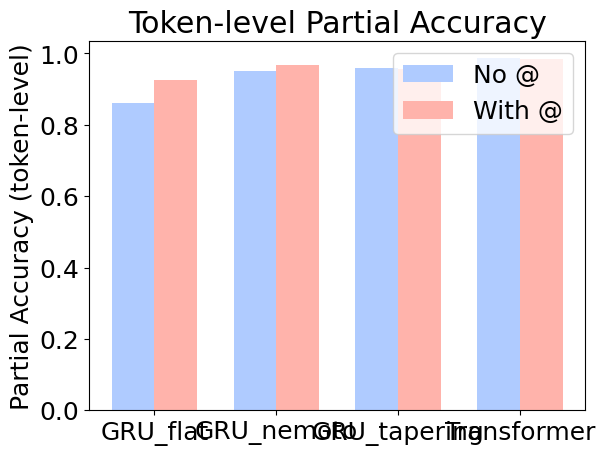

完全一致                   False   True 
model        Answerに@               
GRU_flat     False     37953   41385
             True      57878  162784
GRU_nemoto   False     12975   66363
             True      25964  194698
GRU_tapering False      8525   70813
             True      28389  192273
Transformer  False      2182   77156
             True      11184  209478
          model  has_special      mean       std
0      GRU_flat        False  0.521629  0.230842
1      GRU_flat         True  0.737707  0.079746
2    GRU_nemoto        False  0.836459  0.060029
3    GRU_nemoto         True  0.882336  0.048199
4  GRU_tapering        False  0.892548  0.042612
5  GRU_tapering         True  0.871346  0.075224
6   Transformer        False  0.972497  0.007793
7   Transformer         True  0.949316  0.019307
           model seed  enrichment
0       GRU_flat    1    0.472598
1       GRU_flat    2    0.613032
2       GRU_flat    3    0.644258
3     GRU_nemoto    1    0.581749
4     GRU_nemoto   

/tmp/ipykernel_3756426/3864786924.py:178: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(enrichment_rate)
/tmp/ipykernel_3756426/3864786924.py:197: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calc_or)


In [62]:
import pandas as pd
# === 1. トークンリストを定義 ===
with open("/workspace/clmpy_miyabi/sample/tokens/zinc_normal_tokens.txt") as f:
    TOKENS = [f]

SPECIAL_TOKENS = {"@", "@@"}  
import matplotlib.pyplot as plt
# === 2. 文字列を 1 文字ずつチェックしてトークン化する関数 ===
def tokenize(s):
    tokens = []
    i = 0
    while i < len(s):
        # 2文字トークン "@@" だけ特別扱い
        if s[i:i+2] == "@@":
            tokens.append("@@")
            i += 2
        # 1文字トークン
        elif s[i] in TOKENS:
            tokens.append(s[i])
            i += 1
        else:
            # トークンに該当しない場合は通常の文字列として扱う
            tokens.append(s[i])
            i += 1
    return tokens
def token_compare(ans, pred):
    L = min(len(ans), len(pred))
    return [ans[i] == pred[i] for i in range(L)]
def count_correct_tokens(ans, pred):
    L = min(len(ans), len(pred))
    correct = sum(ans[i] == pred[i] for i in range(L))
    return correct, L
def global_partial_acc(df):
    total_correct = 0
    total_tokens = 0
    for _, r in df.iterrows():
        c, n = count_correct_tokens(r["answer_tok"], r["predict_tok"])
        total_correct += c
        total_tokens += n
    return total_correct / total_tokens if total_tokens > 0 else 0

ALL = []

models = {
    "GRU_nemoto": "/workspace/clmpy_miyabi/result/model_nemoto/251201_Saigen/{seed}/evaluate_result.csv",
    "GRU_tapering": "/workspace/2510_clmpy_paper/result/251106_GRU_tapering{seed}/evaluate_result.csv",
    "GRU_flat": "/workspace/2510_clmpy_paper/result/251106_GRU_flat{seed}/evaluate_result.csv",
    "Transformer": "/workspace/clmpy_miyabi/result/model_nemoto/251219_Saigen_Transformer/{seed}/evaluate_result.csv"
}

records = []
for model_name, path_tmpl in models.items():
    for seed in ["1", "2", "3"]:
        df = pd.read_csv(path_tmpl.format(seed=seed))
        
        df["model"] = model_name
        df["seed"] = seed

        # tokenize
        df["answer_tok"] = df["answer"].apply(tokenize)
        df["predict_tok"] = df["predict"].apply(tokenize)

        # 行正誤
        df["row_correct"] = df.apply(
            lambda r: all(ok for (_, _, ok) in zip(
                r["answer_tok"],
                r["predict_tok"],
                [a == p for a, p in zip(r["answer_tok"], r["predict_tok"])]
            )),
            axis=1
        )
        total_correct = 0
        total_tokens = 0

        for _, r in df.iterrows():
            c, n = count_correct_tokens(r["answer_tok"], r["predict_tok"])
            total_correct += c
            total_tokens += n

        partial_acc = total_correct / total_tokens if total_tokens > 0 else 0

        # @ 有無
        df["has_special"] = df["answer_tok"].apply(
            lambda toks: any(tok in SPECIAL_TOKENS for tok in toks)
        )
        def correct_and_len(ans, pred):
            L = min(len(ans), len(pred))
            c = sum(ans[i] == pred[i] for i in range(L))
            return c, L

        df["tok_len"] = df["answer_tok"].apply(len)
        df[["correct_tok", "eval_len"]] = df.apply(
            lambda r: pd.Series(correct_and_len(r["answer_tok"], r["predict_tok"])),
            axis=1
        )

        for flag in [True, False]:
            sub = df[df["has_special"] == flag]
            pa = global_partial_acc(sub)

            records.append({
                "model": model_name,
                "seed": seed,
                "has_special": flag,
                "partial_accuracy": pa
            })


        ALL.append(df[["model", "seed", "has_special", "row_correct"]])

df_partial = pd.DataFrame(records)
print(df_partial)
plot_df = (
    df_partial
    .groupby(["model", "has_special"])["partial_accuracy"]
    .mean()
    .reset_index()
)

models = plot_df["model"].unique()
x = range(len(models))
width = 0.35

fig, ax = plt.subplots()
color =["#AFCBFF","#FFB3AB"]
vals_no = plot_df[plot_df["has_special"] == False]["partial_accuracy"]
vals_yes = plot_df[plot_df["has_special"] == True]["partial_accuracy"]

ax.bar([i - width/2 for i in x], vals_no, width, label="No @",color=color[0])
ax.bar([i + width/2 for i in x], vals_yes, width, label="With @",color=color[1])

ax.set_xticks(list(x))
ax.set_xticklabels(models)
ax.set_ylabel("Partial Accuracy (token-level)")
ax.set_title("Token-level Partial Accuracy")
ax.legend()

plt.show()

df_all = pd.concat(ALL, ignore_index=True)

ct = pd.crosstab(
    [df_all["model"], df_all["has_special"]],
    df_all["row_correct"],
    rownames=["model", "Answerに@"],
    colnames=["完全一致"]
)

print(ct)
summary = (
    df_all
    .groupby(["model", "seed", "has_special"])["row_correct"]
    .mean()
    .reset_index(name="accuracy")
)

paper_table = (
    summary
    .groupby(["model", "has_special"])["accuracy"]
    .agg(["mean", "std"])
    .reset_index()
)

print(paper_table)
def enrichment_rate(df):
    ct = pd.crosstab(df["has_special"], df["row_correct"])
    if True not in ct.index or False not in ct.index:
        return None
    a = ct.loc[True, False]
    b = ct.loc[True, True]
    c = ct.loc[False, False]
    d = ct.loc[False, True]
    return (a/(a+b)) / (c/(c+d))

enrich = (
    df_all
    .groupby(["model", "seed"])
    .apply(enrichment_rate)
    .reset_index(name="enrichment")
)

print(enrich)

def calc_or(df):
    ct = pd.crosstab(df["has_special"], df["row_correct"])
    if ct.shape != (2, 2):
        return None
    a = ct.loc[True, False]
    b = ct.loc[True, True]
    c = ct.loc[False, False]
    d = ct.loc[False, True]
    return (a * d) / (b * c)

or_table = (
    df_all
    .groupby(["model", "seed"])
    .apply(calc_or)
    .reset_index(name="odds_ratio")
)

print(or_table)


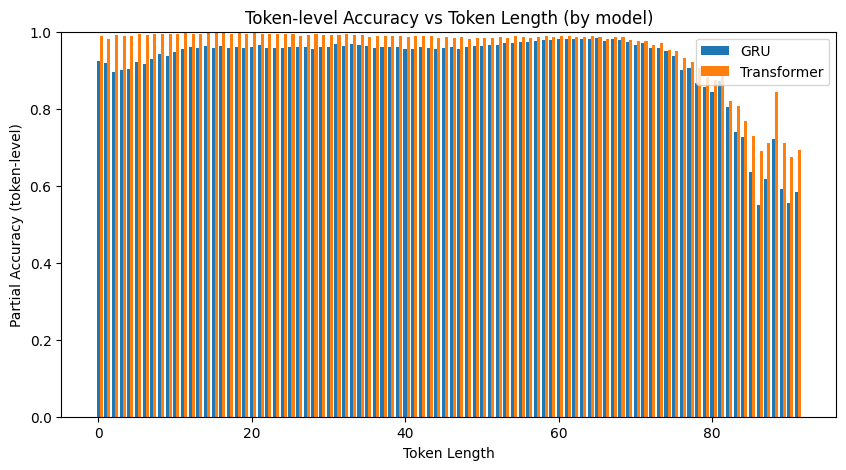

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1. トークン定義
# ==============================
with open("/workspace/clmpy_miyabi/sample/tokens/zinc_normal_tokens.txt") as f:
    TOKENS = [line.strip() for line in f]

SPECIAL_TOKENS = {"@", "@@"}

# ==============================
# 2. tokenize 関数
# ==============================
def tokenize(s):
    tokens = []
    i = 0
    while i < len(s):
        if s[i:i+2] == "@@":
            tokens.append("@@")
            i += 2
        elif s[i] in TOKENS:
            tokens.append(s[i])
            i += 1
        else:
            tokens.append(s[i])
            i += 1
    return tokens

# ==============================
# 3. 正解トークン数・評価長
# ==============================
def correct_and_len(ans, pred):
    L = min(len(ans), len(pred))
    c = sum(ans[i] == pred[i] for i in range(L))
    return c, L

# ==============================
# 4. モデル定義
# ==============================
models = {
    "GRU_nemoto": "/workspace/clmpy_miyabi/result/model_nemoto/251201_Saigen/{seed}/evaluate_result.csv",
    "GRU_tapering": "/workspace/2510_clmpy_paper/result/251106_GRU_tapering{seed}/evaluate_result.csv",
    "GRU_flat": "/workspace/2510_clmpy_paper/result/251106_GRU_flat{seed}/evaluate_result.csv",
    "Transformer": "/workspace/clmpy_miyabi/result/model_nemoto/251219_Saigen_Transformer/{seed}/evaluate_result.csv"
}


dfs = []

# ==============================
# 5. CSV 読み込み
# ==============================
for model_name, path_tmpl in models.items():
    for seed in ["1", "2", "3"]:
        df = pd.read_csv(path_tmpl.format(seed=seed))
        df["model"] = model_name
        df["seed"] = seed

        df["answer_tok"] = df["answer"].apply(tokenize)
        df["predict_tok"] = df["predict"].apply(tokenize)

        df["tok_len"] = df["answer_tok"].apply(len)

        df[["correct_tok", "eval_len"]] = df.apply(
            lambda r: pd.Series(
                correct_and_len(r["answer_tok"], r["predict_tok"])
            ),
            axis=1
        )

        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# ==============================
# 6. model × トークン長 ごとに集計
# ==============================
len_acc = (
    df_all
    .groupby(["model", "tok_len"])
    .agg(
        total_correct=("correct_tok", "sum"),
        total_len=("eval_len", "sum"),
        count=("tok_len", "size")
    )
    .reset_index()
)

len_acc["partial_accuracy"] = (
    len_acc["total_correct"] / len_acc["total_len"]
)

# サンプル数が少ない長さは除外
len_acc = len_acc[len_acc["count"] >= 20]

# ==============================
# 7. ヒストグラム描画（model 別色分け）
# ==============================
models_list = len_acc["model"].unique()
tok_lens = sorted(len_acc["tok_len"].unique())

x = np.arange(len(tok_lens))
width = 0.8 / len(models_list)

plt.figure(figsize=(10, 5))

for i, model_name in enumerate(models_list):
    sub = len_acc[len_acc["model"] == model_name]
    accs = [sub[sub["tok_len"] == L]["partial_accuracy"].values[0]
            if L in sub["tok_len"].values else 0
            for L in tok_lens]

    plt.bar(
        x + i * width,
        accs,
        width,
        label=model_name
    )

plt.xlabel("Token Length")
plt.ylabel("Partial Accuracy (token-level)")
plt.title("Perfect Accuracy per Token Length)")
#plt.xticks(x + width * (len(models_list) - 1) / 2, tok_lens)
plt.ylim(0, 1)
plt.legend()

plt.show()



In [61]:
import pandas as pd
# === 1. トークンリストを定義 ===
with open("/workspace/clmpy_miyabi/sample/tokens/zinc_normal_tokens.txt") as f:
    TOKENS = [f]

SPECIAL_TOKENS = {"@", "@@"}  
import matplotlib.pyplot as plt
# === 2. 文字列を 1 文字ずつチェックしてトークン化する関数 ===
def tokenize(s):
    tokens = []
    i = 0
    while i < len(s):
        # 2文字トークン "@@" だけ特別扱い
        if s[i:i+2] == "@@":
            tokens.append("@@")
            i += 2
        # 1文字トークン
        elif s[i] in TOKENS:
            tokens.append(s[i])
            i += 1
        else:
            # トークンに該当しない場合は通常の文字列として扱う
            tokens.append(s[i])
            i += 1
    return tokens
def token_compare(ans, pred):
    L = min(len(ans), len(pred))
    return [ans[i] == pred[i] for i in range(L)]
def count_correct_tokens(ans, pred):
    L = min(len(ans), len(pred))
    correct = sum(ans[i] == pred[i] for i in range(L))
    return correct, L
def global_partial_acc(df):
    total_correct = 0
    total_tokens = 0
    for _, r in df.iterrows():
        c, n = count_correct_tokens(r["answer_tok"], r["predict_tok"])
        total_correct += c
        total_tokens += n
    return total_correct / total_tokens if total_tokens > 0 else 0

ALL = []

models = {
    "GRU_nemoto": "/workspace/clmpy_miyabi/result/model_nemoto/251201_Saigen/{seed}/evaluate_result.csv",
    "GRU_tapering": "/workspace/2510_clmpy_paper/result/251106_GRU_tapering{seed}/evaluate_result.csv",
    "GRU_flat": "/workspace/2510_clmpy_paper/result/251106_GRU_flat{seed}/evaluate_result.csv",
    "Transformer": "/workspace/clmpy_miyabi/result/model_nemoto/251219_Saigen_Transformer/{seed}/evaluate_result.csv"
}

records = []
path_tmpl = ""
df = pd.read_csv(path_tmpl.format(seed=seed))

df["model"] = model_name
df["seed"] = seed

# tokenize
df["answer_tok"] = df["answer"].apply(tokenize)
df["predict_tok"] = df["predict"].apply(tokenize)

# 行正誤
df["row_correct"] = df.apply(
    lambda r: all(ok for (_, _, ok) in zip(
        r["answer_tok"],
        r["predict_tok"],
        [a == p for a, p in zip(r["answer_tok"], r["predict_tok"])]
    )),
    axis=1
)
total_correct = 0
total_tokens = 0

for _, r in df.iterrows():
    c, n = count_correct_tokens(r["answer_tok"], r["predict_tok"])
    total_correct += c
    total_tokens += n

partial_acc = total_correct / total_tokens if total_tokens > 0 else 0

# @ 有無
df["has_special"] = df["answer_tok"].apply(
    lambda toks: any(tok in SPECIAL_TOKENS for tok in toks)
)
def correct_and_len(ans, pred):
    L = min(len(ans), len(pred))
    c = sum(ans[i] == pred[i] for i in range(L))
    return c, L

df["tok_len"] = df["answer_tok"].apply(len)
df[["correct_tok", "eval_len"]] = df.apply(
    lambda r: pd.Series(correct_and_len(r["answer_tok"], r["predict_tok"])),
    axis=1
)

for flag in [True, False]:
    sub = df[df["has_special"] == flag]
    pa = global_partial_acc(sub)

    records.append({
        "model": model_name,
        "seed": seed,
        "has_special": flag,
        "partial_accuracy": pa
    })


ALL.append(df[["model", "seed", "has_special", "row_correct"]])

df_partial = pd.DataFrame(records)
print(df_partial)
plot_df = (
    df_partial
    .groupby(["model", "has_special"])["partial_accuracy"]
    .mean()
    .reset_index()
)

models = plot_df["model"].unique()
x = range(len(models))
width = 0.35

fig, ax = plt.subplots()
color =["#AFCBFF","#FFB3AB"]
vals_no = plot_df[plot_df["has_special"] == False]["partial_accuracy"]
vals_yes = plot_df[plot_df["has_special"] == True]["partial_accuracy"]

ax.bar([i - width/2 for i in x], vals_no, width, label="No @",color=color[0])
ax.bar([i + width/2 for i in x], vals_yes, width, label="With @",color=color[1])

ax.set_xticks(list(x))
ax.set_xticklabels(models)
ax.set_ylabel("Partial Accuracy (token-level)")
ax.set_title("Token-level Partial Accuracy")
ax.legend()

plt.show()

df_all = pd.concat(ALL, ignore_index=True)

ct = pd.crosstab(
[df_all["model"], df_all["has_special"]],
df_all["row_correct"],
rownames=["model", "Answerに@"],
colnames=["完全一致"]
)

print(ct)
summary = (
    df_all
    .groupby(["model", "seed", "has_special"])["row_correct"]
    .mean()
    .reset_index(name="accuracy")
)

paper_table = (
    summary
    .groupby(["model", "has_special"])["accuracy"]
    .agg(["mean", "std"])
    .reset_index()
)

print(paper_table)
def enrichment_rate(df):
    ct = pd.crosstab(df["has_special"], df["row_correct"])
    if True not in ct.index or False not in ct.index:
        return None
    a = ct.loc[True, False]
    b = ct.loc[True, True]
    c = ct.loc[False, False]
    d = ct.loc[False, True]
    return (a/(a+b)) / (c/(c+d))

enrich = (
    df_all
    .groupby(["model", "seed"])
    .apply(enrichment_rate)
    .reset_index(name="enrichment")
)

print(enrich)

def calc_or(df):
    ct = pd.crosstab(df["has_special"], df["row_correct"])
    if ct.shape != (2, 2):
        return None
    a = ct.loc[True, False]
    b = ct.loc[True, True]
    c = ct.loc[False, False]
    d = ct.loc[False, True]
    return (a * d) / (b * c)

or_table = (
    df_all
    .groupby(["model", "seed"])
    .apply(calc_or)
    .reset_index(name="odds_ratio")
)

print(or_table)


FileNotFoundError: [Errno 2] No such file or directory: ''

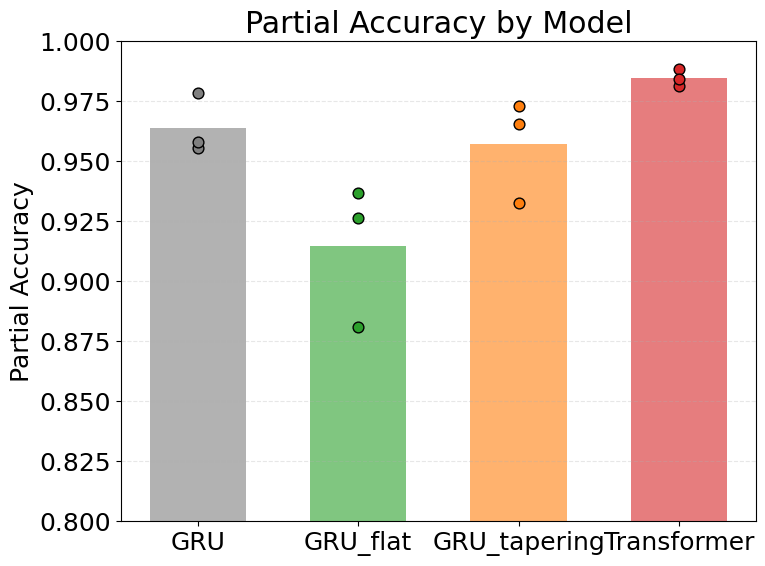

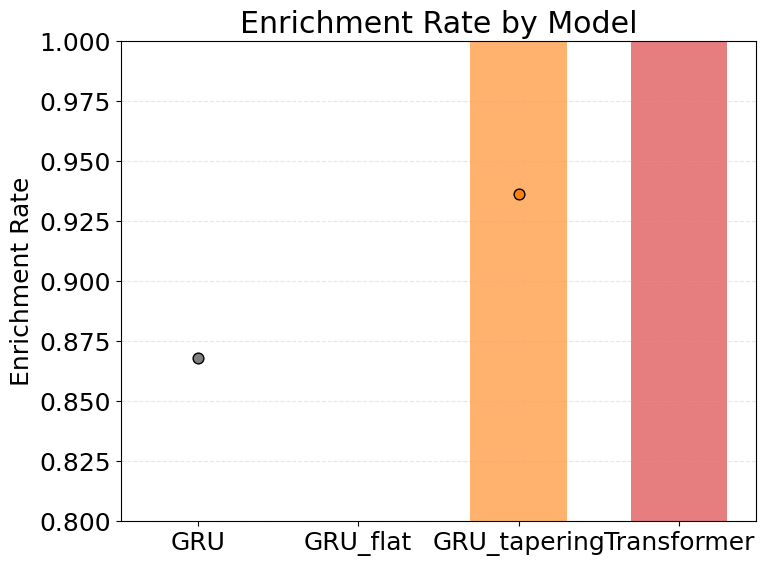

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === 0. モデルの表示順序を定義 ===
# このリストの順番通りにグラフに表示されます
MODEL_ORDER = ["GRU", "GRU_flat", "GRU_tapering", "Transformer"]

# 色の設定（モデルごとに固定）
# 必要に応じて色を変更してください
MODEL_COLORS = {
    "GRU_nemoto": "#1f77b4",   # 青
    "GRU_tapering": "#ff7f0e", # オレンジ
    "GRU_flat": "#2ca02c",     # 緑
    "Transformer": "#d62728"   # 赤
}

# === 1. データ集計の修正（トータルで計算） ===
records_total = []
enrich_records = []

# ※すでに読み込み済みの df_all などを利用する場合を想定していますが、
# ここでは集計ロジックを再掲します。
models = {
    "GRU": "/workspace/clmpy_miyabi/result/model_nemoto/251201_Saigen/{seed}/evaluate_result.csv",
    "GRU_tapering": "/workspace/2510_clmpy_paper/result/251106_GRU_tapering{seed}/evaluate_result.csv",
    "GRU_flat": "/workspace/2510_clmpy_paper/result/251106_GRU_flat{seed}/evaluate_result.csv",
    "Transformer": "/workspace/clmpy_miyabi/result/model_nemoto/251219_Saigen_Transformer/{seed}/evaluate_result.csv"
}


dfs = []

# ==============================
# 5. CSV 読み込み
# ==============================
for model_name, path_tmpl in models.items():
    for seed in ["1", "2", "3"]:
        # CSV読み込みと前処理（既存コードと同様）
        df = pd.read_csv(path_tmpl.format(seed=seed))
        df["answer_tok"] = df["answer"].apply(tokenize)
        df["predict_tok"] = df["predict"].apply(tokenize)
        
        # 行ごとの正誤判定（Enrichment計算用）
        df["row_correct"] = df.apply(
            lambda r: all(a == p for a, p in zip(r["answer_tok"], r["predict_tok"])),
            axis=1
        )
        df["has_special"] = df["answer_tok"].apply(
            lambda toks: any(tok in SPECIAL_TOKENS for tok in toks)
        )

        # --- A. Partial Accuracy (Total) ---
        # @の有無で分割せず、そのシードの全データで計算
        pa_total = global_partial_acc(df)
        records_total.append({
            "model": model_name,
            "seed": seed,
            "partial_accuracy": pa_total
        })

        # --- B. Enrichment Rate ---
        # 既存の関数を利用
        er = enrichment_rate(df)
        if er is not None:
            enrich_records.append({
                "model": model_name,
                "seed": seed,
                "enrichment": er
            })

df_total_partial = pd.DataFrame(records_total)
df_enrich = pd.DataFrame(enrich_records)


# === 2. シンプルなプロット関数（順序指定対応） ===
def plot_by_model(df, y_col, order, title, ylabel, figsize=(8, 6)):
    """
    X軸: Model (order順)
    Y軸: 指定された値 (y_col)
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # モデル名のリスト（X軸の位置）
    x_positions = np.arange(len(order))
    
    # モデルごとにループして描画
    for i, model_name in enumerate(order):
        # そのモデルのデータを取り出す
        subset = df[df["model"] == model_name]
        
        if subset.empty:
            continue
            
        # 平均値（棒グラフ）
        mean_val = subset[y_col].mean()
        color = MODEL_COLORS.get(model_name, "gray")
        
        ax.bar(i, mean_val, width=0.6, color=color, alpha=0.6, label=model_name)
        
        # 個別シードの値（散布図）
        y_vals = subset[y_col].values
        # 棒の中央(i)に点を打つ
        ax.scatter([i] * len(y_vals), y_vals, 
                   color=color, edgecolor='black', s=60, zorder=3)

    # 軸の設定
    ax.set_xticks(x_positions)
    ax.set_xticklabels(order)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    
    # グリッド線（見やすくするため）
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_ylim(0.8,1)
    plt.tight_layout()
    plt.show()

# === 3. グラフの作成 ===

# (1) Partial Accuracy (Total)
plot_by_model(
    df=df_total_partial,
    y_col="partial_accuracy",
    order=MODEL_ORDER,
    title="Partial Accuracy by Model",
    ylabel="Partial Accuracy"
)

# (2) Enrichment Rate
plot_by_model(
    df=df_enrich,
    y_col="enrichment",
    order=MODEL_ORDER,
    title="Enrichment Rate by Model",
    ylabel="Enrichment Rate"
)

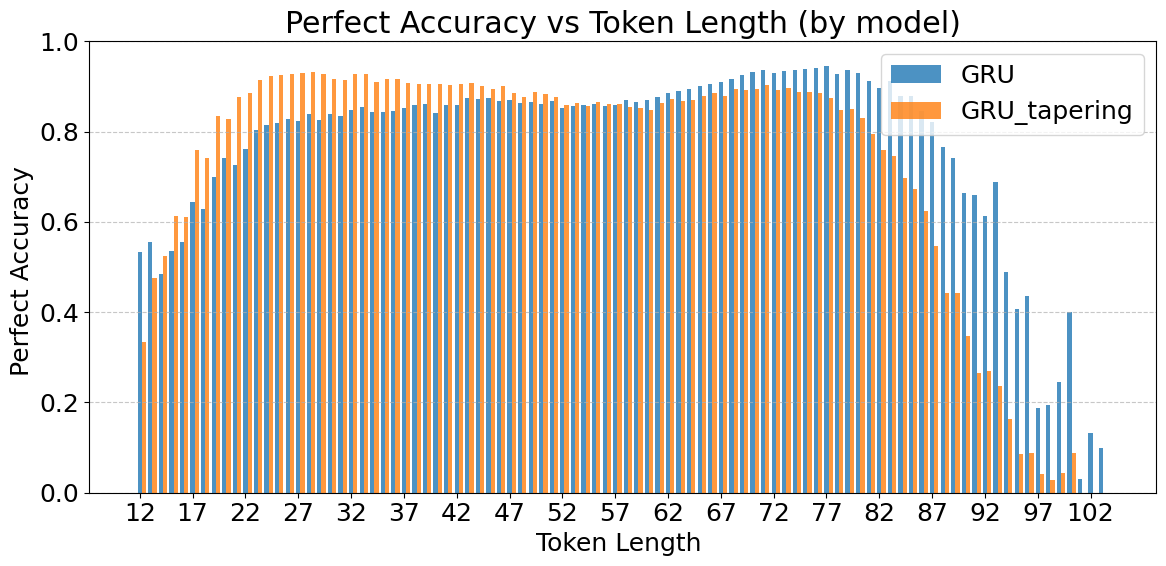

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. トークン定義 (変更なし)
# ==============================
# ※ 実行環境に合わせてパスを確認してください
with open("/workspace/clmpy_miyabi/sample/tokens/zinc_normal_tokens.txt") as f:
    TOKENS = [line.strip() for line in f]

SPECIAL_TOKENS = {"@", "@@"}

# ==============================
# 2. tokenize 関数 (変更なし)
# ==============================
def tokenize(s):
    tokens = []
    i = 0
    while i < len(s):
        if s[i:i+2] == "@@":
            tokens.append("@@")
            i += 2
        elif s[i] in TOKENS:
            tokens.append(s[i])
            i += 1
        else:
            tokens.append(s[i])
            i += 1
    return tokens

# ==============================
# 3. モデル定義 (変更なし)
# ==============================
models = {
    "GRU": "/workspace/clmpy_miyabi/result/model_nemoto/251201_Saigen/{seed}/evaluate_result.csv",
    "GRU_tapering": "/workspace/2510_clmpy_paper/result/251106_GRU_tapering{seed}/evaluate_result.csv",
}
# models = {
#     "GRU": "/workspace/clmpy_miyabi/result/model_nemoto/251201_Saigen/{seed}/evaluate_result.csv",
#     "Transformer": "/workspace/clmpy_miyabi/result/model_nemoto/251219_Saigen_Transformer/{seed}/evaluate_result.csv"
# }

dfs = []

# ==============================
# 4. CSV 読み込み & Perfect判定
# ==============================
for model_name, path_tmpl in models.items():
    for seed in ["1", "2", "3"]:
        try:
            # ファイルが存在しない場合のエラーハンドリングを追加推奨
            df = pd.read_csv(path_tmpl.format(seed=seed))
        except FileNotFoundError:
            print(f"Warning: File not found for {model_name} seed {seed}")
            continue

        df["model"] = model_name
        df["seed"] = seed

        # トークン化
        df["answer_tok"] = df["answer"].apply(tokenize)
        df["predict_tok"] = df["predict"].apply(tokenize)

        # トークン長（X軸用）
        df["tok_len"] = df["answer_tok"].apply(len)

        # --- 【変更点】Perfect Accuracy (完全一致) の判定 ---
        # リスト同士が完全に等しい場合のみ 1、それ以外は 0
        df["is_perfect"] = df.apply(
            lambda row: 1 if row["answer_tok"] == row["predict_tok"] else 0,
            axis=1
        )

        dfs.append(df)

if not dfs:
    raise ValueError("データフレームが空です。パスを確認してください。")

df_all = pd.concat(dfs, ignore_index=True)

# ==============================
# 5. model × トークン長 ごとに集計
# ==============================
len_acc = (
    df_all
    .groupby(["model", "tok_len"])
    .agg(
        perfect_count=("is_perfect", "sum"),  # 完全一致した数
        count=("is_perfect", "size")          # その長さのデータの総数
    )
    .reset_index()
)

# Perfect Accuracy の計算
len_acc["perfect_accuracy"] = len_acc["perfect_count"] / len_acc["count"]

# サンプル数が少ない長さは除外（ノイズ対策）
len_acc = len_acc[len_acc["count"] >= 20]

# ==============================
# 6. ヒストグラム描画
# ==============================
models_list = len_acc["model"].unique()
tok_lens = sorted(len_acc["tok_len"].unique())

x = np.arange(len(tok_lens))
width = 0.8 / len(models_list)
plt.rcParams["font.size"] = 18

plt.figure(figsize=(12, 6))

for i, model_name in enumerate(models_list):
    sub = len_acc[len_acc["model"] == model_name]
    
    # 該当する長さのデータがない場合は0埋め
    accs = [sub[sub["tok_len"] == L]["perfect_accuracy"].values[0]
            if L in sub["tok_len"].values else 0
            for L in tok_lens]

    plt.bar(
        x + i * width,
        accs,
        width,
        label=model_name,
        alpha=0.8
    )

plt.xlabel("Token Length ")
plt.ylabel("Perfect Accuracy ")
plt.title("Perfect Accuracy vs Token Length (by model)")

# X軸のメモリ設定（見やすさのため調整）
# データ点数が多い場合、間引いて表示することを推奨
if len(tok_lens) > 20:
    step = 5
    plt.xticks(x[::step], tok_lens[::step])
else:
    plt.xticks(x + width * (len(models_list) - 1) / 2, tok_lens)

plt.ylim(0, 1) # 1.0より少し上に余裕を持たせる
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.show()

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. トークン定義 (変更なし)
# ==============================
with open("/workspace/clmpy_miyabi/sample/tokens/zinc_normal_tokens.txt") as f:
    TOKENS = [line.strip() for line in f]

SPECIAL_TOKENS = {"@", "@@"}

# ==============================
# 2. tokenize 関数 (変更なし)
# ==============================
def tokenize(s):
    tokens = []
    i = 0
    while i < len(s):
        if s[i:i+2] == "@@":
            tokens.append("@@")
            i += 2
        elif s[i] in TOKENS:
            tokens.append(s[i])
            i += 1
        else:
            tokens.append(s[i])
            i += 1
    return tokens

# ==============================
# 3. モデル定義 (変更なし)
# ==============================
models = {
    "GRU": "/workspace/clmpy_miyabi/result/model_nemoto/251201_Saigen/{seed}/evaluate_result.csv",
    # "GRU_tapering": "/workspace/2510_clmpy_paper/result/251106_GRU_tapering{seed}/evaluate_result.csv",
    # "GRU_flat": "/workspace/2510_clmpy_paper/result/251106_GRU_flat{seed}/evaluate_result.csv",
    "Transformer": "/workspace/clmpy_miyabi/result/model_nemoto/251219_Saigen_Transformer/{seed}/evaluate_result.csv"
}


dfs = []

# ==============================
# 4. CSV 読み込み & Perfect判定
# ==============================
for model_name, path_tmpl in models.items():
    for seed in ["1", "2", "3"]:
        try:
            df = pd.read_csv(path_tmpl.format(seed=seed))
        except FileNotFoundError:
            print(f"Warning: File not found for {model_name} seed {seed}")
            continue

        df["model"] = model_name
        df["seed"] = seed

        # トークン化
        df["answer_tok"] = df["answer"].apply(tokenize)
        df["predict_tok"] = df["predict"].apply(tokenize)

        # トークン長（X軸用）
        df["tok_len"] = df["answer_tok"].apply(len)

        # Perfect Accuracy (完全一致) の判定
        df["is_perfect"] = df.apply(
            lambda row: 1 if row["answer_tok"] == row["predict_tok"] else 0,
            axis=1
        )

        dfs.append(df)

if not dfs:
    raise ValueError("データフレームが空です。パスを確認してください。")

df_all = pd.concat(dfs, ignore_index=True)

# ==============================
# 5.5 【追加】短いトークン長のデータを保存
# ==============================
# tok_len が 10 以下の行を抽出
df_short = df_all[df_all["tok_len"] <= 20].copy()

# 見やすいように モデル -> 長さ -> seed の順でソート
df_short = df_short.sort_values(by=["model", "tok_len", "seed"])

# 必要なカラムだけ選んで保存（必要に応じてカラムは調整してください）
out_columns = ["model", "seed", "tok_len", "is_perfect", "answer", "predict", "answer_tok", "predict_tok"]
#save_path = "short_tokens_len20_or_less.csv"

# CSV出力
df_short[out_columns].to_csv(save_path, index=False)
print(f"Saved {len(df_short)} samples with tok_len <= 10 to: {save_path}")


Saved 7860 samples with tok_len <= 10 to: short_tokens_len20_or_less.csv


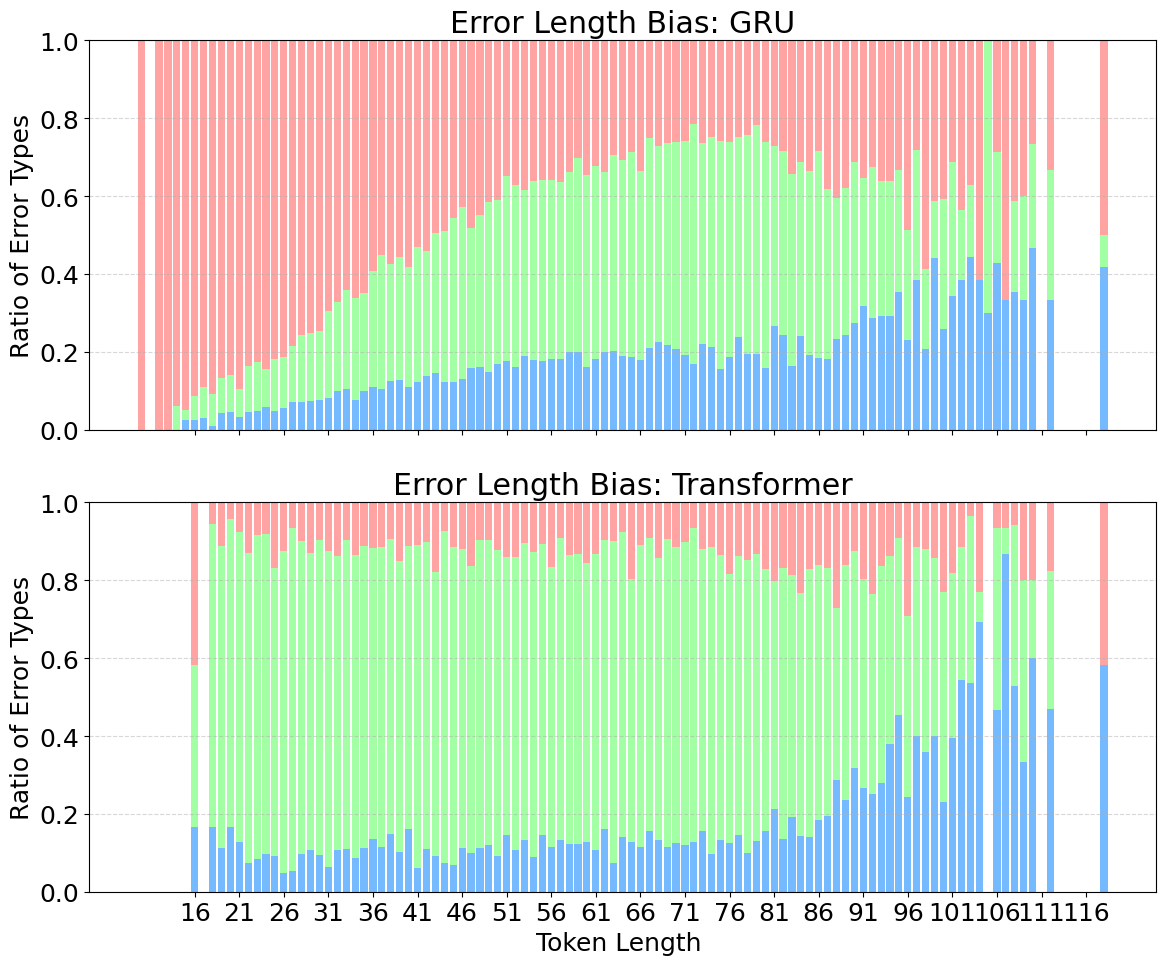

In [60]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==============================
# 1. 不正解データの抽出とカテゴリ分け
# ==============================
# 完全一致していないデータのみ対象
df_ng = df_all[df_all["is_perfect"] == 0].copy()

# 予測の長さが 正解より「長い」か「短い」か「同じ」かを判定
def classify_len_error(row):
    ans_len = len(row["answer_tok"])
    pred_len = len(row["predict_tok"])
    
    if pred_len > ans_len:
        return "Longer (Predict > Answer)"
    elif pred_len < ans_len:
        return "Shorter (Predict < Answer)"
    else:
        return "Same Length (Wrong Content)"

df_ng["error_type"] = df_ng.apply(classify_len_error, axis=1)

# ==============================
# 2. 集計 (Model x TokenLen x ErrorType)
# ==============================
# モデルごと、トークン長ごとに、エラータイプの内訳をカウント
error_counts = df_ng.groupby(["model", "tok_len", "error_type"]).size().unstack(fill_value=0)

# エラーデータの総数が少ない長さ（ノイズ）を除外（例: その長さでの不正解が10個未満なら表示しない）
min_error_samples = 10
row_sums = error_counts.sum(axis=1)
error_counts = error_counts[row_sums >= min_error_samples]
plt.rcParams["font.size"] = 18
# 割合（%）に変換
error_ratios = error_counts.div(error_counts.sum(axis=1), axis=0)

# ==============================
# 3. プロット (積み上げ棒グラフ)
# ==============================
models_list = df_all["model"].unique()
fig, axes = plt.subplots(len(models_list), 1, figsize=(12, 5 * len(models_list)), sharex=True)

# 凡例の順番を固定
category_order = ["Shorter (Predict < Answer)", "Same Length (Wrong Content)", "Longer (Predict > Answer)"]
colors = ["#66b3ff", "#99ff99", "#ff9999"]  # 青(短い), 緑(同長), 赤(長い)

if len(models_list) == 1:
    axes = [axes]

for ax, model_name in zip(axes, models_list):
    if model_name not in error_ratios.index.get_level_values(0):
        ax.text(0.5, 0.5, "No Error Data", ha='center')
        continue

    # そのモデルのデータだけ抽出
    data = error_ratios.loc[model_name]
    
    # 存在しないカラムがあれば0埋めして補完
    for cat in category_order:
        if cat not in data.columns:
            data[cat] = 0
    
    data = data[category_order] # 順番揃え
    
    # 積み上げ棒グラフ描画
    x = data.index
    bottom = np.zeros(len(x))
    
    for i, cat in enumerate(category_order):
        ax.bar(x, data[cat], bottom=bottom, label=cat, color=colors[i], width=0.8, alpha=0.9)
        bottom += data[cat].values

    ax.set_title(f"Error Length Bias: {model_name}")
    ax.set_ylabel("Ratio of Error Types")
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # X軸の設定
    if len(x) > 0:
        step = 5 if (max(x) - min(x)) > 30 else 1
        ax.set_xticks(np.arange(min(x), max(x)+1, step))

# 共通のラベルと凡例
axes[-1].set_xlabel("Token Length ")
# 凡例は1つにまとめる
handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3)


plt.tight_layout()
plt.show()

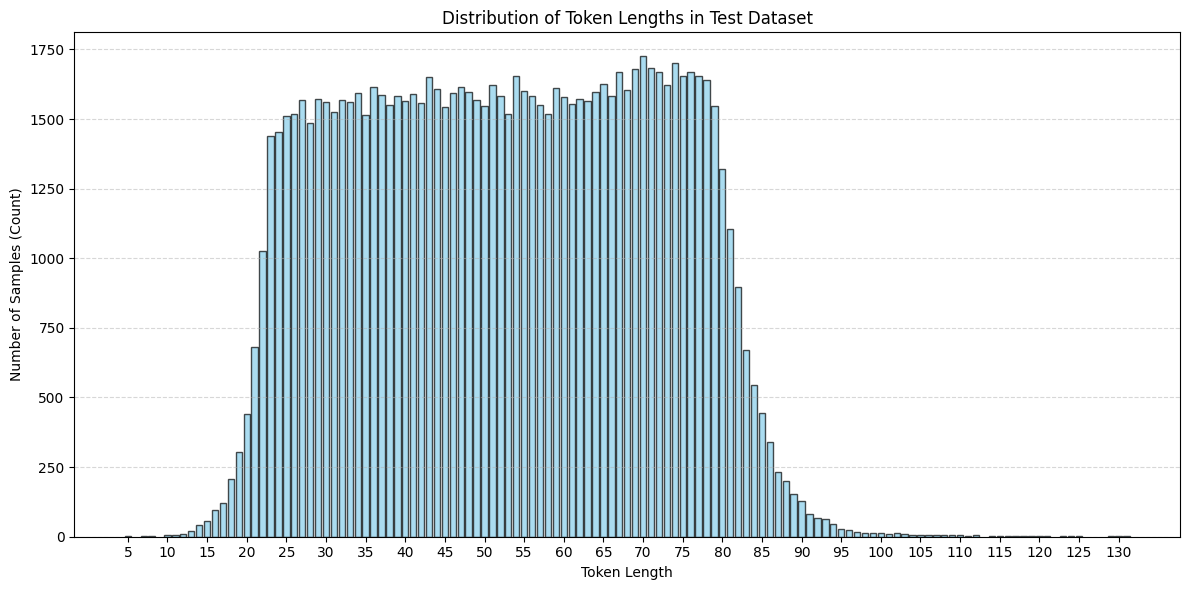

=== Token Length Counts (Top 10 frequent lengths) ===
tok_len
70    1725
74    1701
71    1683
69    1681
72    1669
67    1669
76    1668
75    1656
77    1655
54    1653
Name: count, dtype: int64

=== Statistics ===
count    100000.000000
mean         52.573240
std          18.515889
min           5.000000
25%          37.000000
50%          53.000000
75%          68.000000
max         131.000000
Name: tok_len, dtype: float64


In [40]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# ヒストグラム描画 (データセットの分布確認)
# ==============================

# 1. 重複を除外して、テストデータセット1つ分だけのデータを抽出
# (モデルやシードに関わらず正解データ(answer)は同じはずなので、1つの設定だけ抜き出します)
# ここでは例として GRU の seed=1 を代表として使います
df_dataset = df_all[(df_all["model"] == "GRU") & (df_all["seed"] == "1")]

# もし GRU seed 1 がロードされていない場合は、単に answer で重複削除します
if df_dataset.empty:
    df_dataset = df_all.drop_duplicates(subset=["answer"])

# 2. 集計
counts = df_dataset["tok_len"].value_counts().sort_index()

# 3. 描画
plt.figure(figsize=(12, 6))

# 棒グラフでヒストグラム的に表示 (離散値なので bar が見やすいです)
plt.bar(counts.index, counts.values, width=0.8, color='skyblue', edgecolor='black', alpha=0.7)

plt.xlabel("Token Length")
plt.ylabel("Number of Samples (Count)")
plt.title("Distribution of Token Lengths in Test Dataset")

# X軸の目盛り調整 (データが存在する範囲で見やすく)
min_len = counts.index.min()
max_len = counts.index.max()

# 目盛りが多すぎる場合は間引く
if max_len - min_len > 30:
    plt.xticks(np.arange(min_len, max_len + 1, 5))
else:
    plt.xticks(np.arange(min_len, max_len + 1, 1))

plt.grid(axis='y', linestyle='--', alpha=0.5)

# データ数が極端に少ないところ(ノイズになりやすい箇所)を確認しやすくするため、対数軸にするオプション
# plt.yscale('log') # 必要であればコメントアウトを外してください

plt.tight_layout()
plt.show()

# 4. 具体的な数値の確認 (上位10個の長さ)
print("=== Token Length Counts (Top 10 frequent lengths) ===")
print(counts.sort_values(ascending=False).head(10))

print("\n=== Statistics ===")
print(df_dataset["tok_len"].describe())

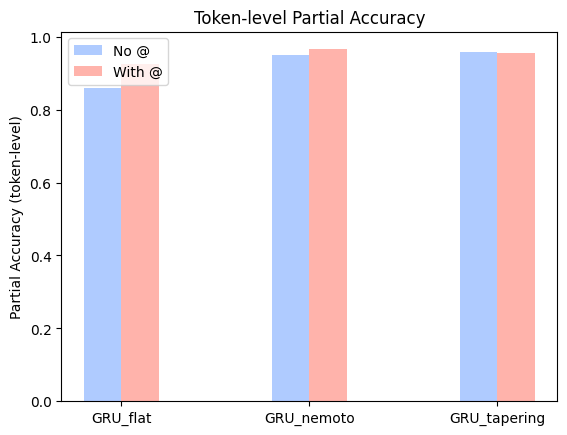

In [15]:
width = 0.2
fig, ax = plt.subplots()
color =["#AFCBFF","#FFB3AB"]
vals_no = plot_df[plot_df["has_special"] == False]["partial_accuracy"]
vals_yes = plot_df[plot_df["has_special"] == True]["partial_accuracy"]

ax.bar([i - width/2 for i in x], vals_no, width, label="No @",color=color[0])
ax.bar([i + width/2 for i in x], vals_yes, width, label="With @",color=color[1])

ax.set_xticks(list(x))
ax.set_xticklabels(models)
ax.set_ylabel("Partial Accuracy (token-level)")
ax.set_title("Token-level Partial Accuracy")
ax.legend()

plt.show()

In [36]:
from collections import defaultdict
import pandas as pd
# === 1. トークンリストを定義 ===
with open("/workspace/clmpy_miyabi/sample/tokens/zinc_normal_tokens.txt") as f:
    TOKENS = [f]
def token_type(tok):
    if tok in {"@", "@@"}:
        return "SPECIAL"
    # elif tok.isdigit():
    #     return "DIGIT"
    # elif tok.isalpha():
    #     return "ALPHA"
    else:
        return "OTHER"

SPECIAL_TOKENS = {"@", "@@"}  
import matplotlib.pyplot as plt
# === 2. 文字列を 1 文字ずつチェックしてトークン化する関数 ===
def tokenize(s):
    tokens = []
    i = 0
    while i < len(s):
        # 2文字トークン "@@" だけ特別扱い
        if s[i:i+2] == "@@":
            tokens.append("@@")
            i += 2
        # 1文字トークン
        elif s[i] in TOKENS:
            tokens.append(s[i])
            i += 1
        else:
            # トークンに該当しない場合は通常の文字列として扱う
            tokens.append(s[i])
            i += 1
    return tokens

def token_type_partial_acc(df):
    correct = defaultdict(int)
    total = defaultdict(int)

    for _, r in df.iterrows():
        ans = r["answer_tok"]
        pred = r["predict_tok"]
        L = min(len(ans), len(pred))

        for i in range(L):
            ttype = token_type(ans[i])
            total[ttype] += 1
            if ans[i] == pred[i]:
                correct[ttype] += 1

    rows = []
    for ttype in total:
        rows.append({
            "token_type": ttype,
            "partial_accuracy": correct[ttype] / total[ttype],
            "count": total[ttype]
        })

    return pd.DataFrame(rows)

ALL = []

models = {
    "GRU_nemoto": "/workspace/clmpy_miyabi/result/model_nemoto/251201_Saigen/{seed}/evaluate_result.csv",
    "GRU_tapering": "/workspace/2510_clmpy_paper/result/251106_GRU_tapering{seed}/evaluate_result.csv",
    "GRU_flat": "/workspace/2510_clmpy_paper/result/251106_GRU_flat{seed}/evaluate_result.csv",
    "Transformer": "/workspace/clmpy_miyabi/result/model_nemoto/251219_Saigen_Transformer/{seed}/evaluate_result.csv"
}

records = []

for model_name, path_tmpl in models.items():
    for seed in ["1", "2", "3"]:
        df = pd.read_csv(path_tmpl.format(seed=seed))
        df["answer_tok"] = df["answer"].apply(tokenize)
        df["predict_tok"] = df["predict"].apply(tokenize)

        res = token_type_partial_acc(df)
        res["model"] = model_name
        res["seed"] = seed
        records.append(res)

df_token_type = pd.concat(records, ignore_index=True)
print(df_token_type)



   token_type  partial_accuracy    count         model seed
0       OTHER          0.978770  5059546    GRU_nemoto    1
1     SPECIAL          0.969644   192847    GRU_nemoto    1
2       OTHER          0.956033  5057721    GRU_nemoto    2
3     SPECIAL          0.944132   192795    GRU_nemoto    2
4       OTHER          0.958806  5056783    GRU_nemoto    3
5     SPECIAL          0.939634   192824    GRU_nemoto    3
6       OTHER          0.966614  5053285  GRU_tapering    1
7     SPECIAL          0.939059   192611  GRU_tapering    1
8       OTHER          0.934577  5039033  GRU_tapering    2
9     SPECIAL          0.883187   192188  GRU_tapering    2
10      OTHER          0.973749  5056865  GRU_tapering    3
11    SPECIAL          0.952020   192663  GRU_tapering    3
12      OTHER          0.880881  5048645      GRU_flat    1
13    SPECIAL          0.882596   192429      GRU_flat    1
14      OTHER          0.937965  5051743      GRU_flat    2
15    SPECIAL          0.910766   192673

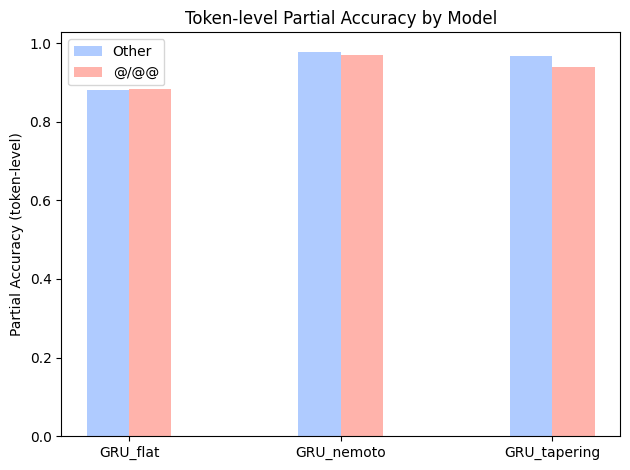

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = df_token_type["model"].unique()
model_order = ["GRU_flat", "GRU_nemoto", "GRU_tapering"]
models = model_order
x = np.arange(len(models))

width = 0.2

fig, ax = plt.subplots()

color = ["#AFCBFF", "#FFB3AB"]

vals_no = [
    df_token_type[(df_token_type["model"] == m) & (df_token_type["token_type"] == "OTHER")]
    ["partial_accuracy"].values[0]
    for m in models
]

vals_yes = [
    df_token_type[(df_token_type["model"] == m) & (df_token_type["token_type"] == "SPECIAL")]
    ["partial_accuracy"].values[0]
    for m in models
]

ax.bar(
    [i - width/2 for i in x],
    vals_no,
    width,
    label="Other",
    color=color[0]
)

ax.bar(
    [i + width/2 for i in x],
    vals_yes,
    width,
    label="@/@@",
    color=color[1]
)

ax.set_xticks(list(x))
ax.set_xticklabels(models)
ax.set_ylabel("Partial Accuracy (token-level)")
ax.set_title("Token-level Partial Accuracy by Model")
ax.legend()

plt.tight_layout()
plt.show()


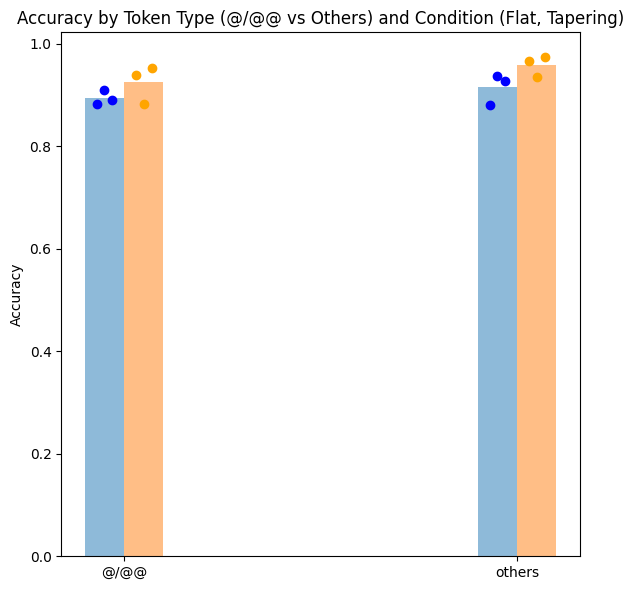

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# --- Example dummy data (replace with your real dataframe) ---
# Columns required: model, condition, group("@/@@" or "others"), accuracy
df = pd.DataFrame({
    "condition": ["Flat","Flat","Flat","Flat","Flat","Flat","Tapering","Tapering","Tapering","Tapering","Tapering","Tapering"],
    "group": ["@/@@","others","@/@@","others","@/@@","others","@/@@","others","@/@@","others","@/@@","others"],
    "accuracy": [0.882596,0.880881,0.910766,00.937965,0.8913,0.92750,0.939059,0.9666,0.8831,0.9345,0.9520,0.9737]
})
df["model"] = ["M1","M1","M2","M2","M3","M3",
               "M1","M1","M2","M2","M3","M3"]
# --- Plot ---
token_groups = ["@/@@", "others"]
conditions = ["Flat", "Tapering"]
models = df["model"].unique()


# === Prepare figure ===
plt.figure(figsize=(6,6))

x = np.arange(len(token_groups))  # two token groups
width = 0.1                # two bars per group (Flat, Tapering)

# === Plot bars (mean accuracy by condition) ===
for i, cond in enumerate(conditions):
    accs = [
        df[(df["group"] == g) & (df["condition"] == cond)]["accuracy"].mean()
        for g in token_groups
    ]
    plt.bar(x + (i+0.001)*width, accs,width=width, alpha=0.5)
condition_colors = {
    "Flat": "blue",
    "Tapering": "orange"
}

# --- Model points (色は条件で統一) ---
for k, model in enumerate(models):
    for i, cond in enumerate(conditions):
        for j, g in enumerate(token_groups):
            subset = df[(df["model"] == model) &
                        (df["condition"] == cond) &
                        (df["group"] == g)]
            if len(subset) > 0:
                # slight offset to avoid overlap
                offset = (k - 1) * 0.02
                plt.plot(
                    x[j] + i*width + offset,
                    subset["accuracy"].iloc[0],
                    marker='o',
                    color=condition_colors[cond]   # ← 条件に応じて色を固定
                )


plt.xticks(x + width/2, token_groups)
plt.ylabel("Accuracy")
plt.title("Accuracy by Token Type (@/@@ vs Others) and Condition (Flat, Tapering)")

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def _eval_sample(self, source, target, device):
    # バッチサイズ1に限定
    source = source[:, 0].unsqueeze(1).to(device)  # (seq_len, 1)
    target = target[:, 0].unsqueeze(1).to(device)

    # EncoderでAttention取得
    mu, log_var, attentions = self.model.encoder(source, output_attentions=True)

    # Latentサンプリング
    latent = self.model.sampling(mu, log_var)

    # デコーダ生成
    maxlen = self.maxlen
    token_ids = torch.zeros((maxlen, 1), dtype=torch.long, device=device)
    token_ids[0, 0] = 1  # BOSトークン

    for i in range(1, maxlen):
        out = self.model.decoder(token_ids[:i, :], latent)
        _, out_id = out.max(dim=2)
        new_id = out_id[-1, :]
        if token_ids[i-1, 0] in [0, 2]:  # PAD or EOS
            token_ids = token_ids[:i, :]
            break
        token_ids[i, :] = new_id

    pred = token_ids[1:, 0]

    # SMILES文字列に変換
    id2sm = self.id2sm
    x_str = "".join([id2sm[i.item()] for i in source[:,0][1:]]).split(id2sm[2])[0]
    y_str = "".join([id2sm[i.item()] for i in target[:,0][1:]]).split(id2sm[2])[0]
    p_str = "".join([id2sm[i.item()] for i in pred]).split(id2sm[2])[0]

    # ---- Attention可視化 ----
    # attentions: (num_layers, num_heads, seq_len, seq_len)
    # バッチサイズ1なので [0] で取り出し
    for layer_idx, layer_att in enumerate(attentions):
        for head_idx, head_att in enumerate(layer_att):
            plt.figure(figsize=(8,6))
            sns.heatmap(head_att.detach().cpu().numpy(), xticklabels=list(x_str), yticklabels=list(p_str))
            plt.xlabel("Input tokens")
            plt.ylabel("Output tokens")
            plt.title(f"Layer {layer_idx+1}, Head {head_idx+1}")
            plt.show()

    judge = (y_str == p_str)
    return {"input": x_str, "answer": y_str, "predict": p_str, "judge": judge, "attention": attentions}


In [ ]:
args = get_args() 
test_data = pd.read_csv(args.test_path,index_col=0) 
#test_data = test_data[test_data["Class"] == "test"] 
model = TransformerVAE(args) 
evaluator = Evaluator(model,args) 
results = evaluator.evaluate(test_data) 


In [ ]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

for i in ["1_1","1_2","1_3","78_1","78_2","78_3"]:
        
    save_dir = f"/workspace/clmpy_miyabi/result/model_nemoto/251108_Transformer_VAE_attention/{i}"

    csv_files = glob.glob(os.path.join(save_dir, "*_stats.csv"))

    dfs = []
    for f in csv_files:
        df = pd.read_csv(f, index_col=0)

        # --- ★ 対角成分の除外処理 ★ ---
        attn = df.values.astype(float)
        np.fill_diagonal(attn, 0.0)  # 対角をゼロにする
        row_sums = attn.sum(axis=1, keepdims=True)
        attn = np.divide(attn, row_sums, where=row_sums!=0)

        df_no_diag = pd.DataFrame(attn, index=df.index, columns=df.columns)

        dfs.append(df_no_diag)

    # CSV を縦に結合
    all_tokens = pd.concat(dfs, axis=0)

    # トークンごとに平均と標準偏差
    summary = all_tokens.groupby(all_tokens.index).agg(["mean", "std"])

    summary.columns = ["mean_of_mean", "std_of_mean", "mean_of_std", "std_of_std"]

    print(summary)

    # --- グラフ ---
    df_plot = summary.sort_values(by="mean_of_mean", ascending=False)

    plt.figure(figsize=(12, 6))
    plt.bar(df_plot.index, df_plot["mean_of_mean"],
            yerr=df_plot["std_of_mean"], capsize=4)
    plt.xticks(rotation=90, fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("Tokens", fontsize=14)
    plt.ylabel("Mean Attention (No Diagonal)", fontsize=14)
    plt.title(f"Token-wise Attention (diag removed) - {i}", fontsize=16)
    plt.tight_layout()
    plt.show()


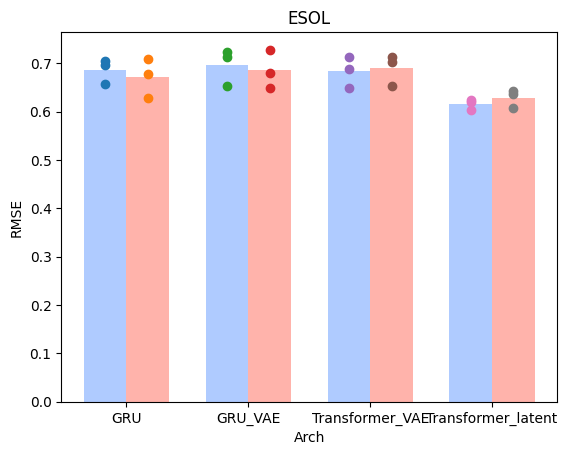

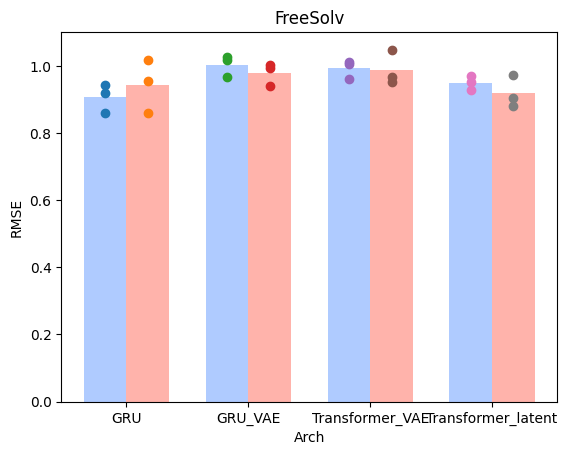

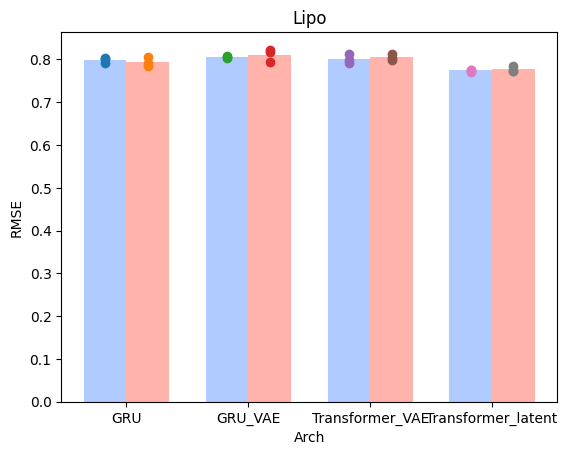

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#for inn in ["BACE","BBBP","Clintox"]:

for inn in ["ESOL","FreeSolv","Lipo"]:
    df = pd.read_csv("./ss.csv")

    df = df[df["Task"]==inn]
    # プロット準備
    pivot = df.groupby(["Arch", "SFL"])["predict"].mean().unstack()

    # プロット準備
    x = np.arange(len(pivot.index))   # Arch の位置
    width = 0.35

    fig, ax = plt.subplots()
    color =["#AFCBFF","#FFB3AB"]

    for i, sfl in enumerate(pivot.columns):
        ax.bar(x + i*width, pivot[sfl], width,color=color[i], label=sfl)


    # --- 各点の散布図 ---
    for i, arch in enumerate(pivot.index):
        for j, sfl in enumerate(pivot.columns):
            # 該当するデータ抽出
            pts = df[(df["Arch"] == arch) & (df["SFL"] == sfl)]["predict"]
            # バーの中央に少し散らして描画
            ax.scatter(
                np.full(len(pts), x[i] + j*width ),
                pts,
                marker='o'
            )

    ax.set_xticks(x + width/2)
    ax.set_xticklabels(pivot.index)
    ax.set_xlabel("Arch")
    ax.set_ylabel("RMSE")
    ax.set_title(inn)

    plt.show()



In [51]:
import torch

obj = torch.load("/workspace/clmpy_miyabi/models/best_model.pt", map_location="cpu", weights_only=True)
print(type(obj))
sd = obj  # OrderedDict

for k in list(sd.keys())[:30]:
    print(k)


<class 'collections.OrderedDict'>
encoder.wte.weight
encoder.wpe.pe
encoder.h.0.ln_1.weight
encoder.h.0.ln_1.bias
encoder.h.0.attn.c_attn.weight
encoder.h.0.attn.c_attn.bias
encoder.h.0.attn.c_proj.weight
encoder.h.0.attn.c_proj.bias
encoder.h.0.ln_2.weight
encoder.h.0.ln_2.bias
encoder.h.0.mlp.c_fc.weight
encoder.h.0.mlp.c_fc.bias
encoder.h.0.mlp.c_proj.weight
encoder.h.0.mlp.c_proj.bias
encoder.h.1.ln_1.weight
encoder.h.1.ln_1.bias
encoder.h.1.attn.c_attn.weight
encoder.h.1.attn.c_attn.bias
encoder.h.1.attn.c_proj.weight
encoder.h.1.attn.c_proj.bias
encoder.h.1.ln_2.weight
encoder.h.1.ln_2.bias
encoder.h.1.mlp.c_fc.weight
encoder.h.1.mlp.c_fc.bias
encoder.h.1.mlp.c_proj.weight
encoder.h.1.mlp.c_proj.bias
encoder.h.2.ln_1.weight
encoder.h.2.ln_1.bias
encoder.h.2.attn.c_attn.weight
encoder.h.2.attn.c_attn.bias


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from scipy.spatial.distance import mahalanobis

class ScopeDetector:
    def __init__(self, model, device='cpu'):
        """
        model: 学習済みの TransformerLatent_MLP モデル
        device: 'cuda:0' or 'cpu'
        """
        self.model = model
        self.device = device
        self.model.to(self.device)
        self.model.eval()
        
        # 統計量
        self.train_latent_mean = None
        self.train_latent_cov_inv = None
        self.threshold_distance = None
        self.threshold_recon_loss = None

    def fit(self, train_loader, percentile=99):
        """
        学習データを使って、適用範囲の「境界線（閾値）」を決定する。
        
        Args:
            train_loader: 学習に使ったデータのDataLoader
                          ((source, target), target_mlp) を返すものと想定
            percentile: 閾値を決めるパーセンタイル (例: 99%のデータが含まれる範囲とする)
        """
        print("Calibrating scope with training data...")
        latent_vectors = []
        recon_losses = []
        
        # 損失関数（再構成誤差用）：Reduction=Noneでサンプルごとの誤差を取得
        criterion = nn.CrossEntropyLoss(ignore_index=0, reduction='none')

        with torch.no_grad():
            for batch in train_loader:
                # DataLoaderの形式に合わせて展開 ((source, target), target_mlp)
                # もし形式が違う場合はここを調整してください
                if len(batch) == 2 and isinstance(batch[0], (list, tuple)):
                     (source, target), _ = batch
                else:
                    # 簡易的なフォールバック
                    source, target = batch[0], batch[1]

                source = source.to(self.device)
                target = target.to(self.device)

                # 1. Encoderで潜在変数を取得
                # model.encoder(source) は (Batch, EmbeddingDim) を返す
                latent = self.model.encoder(source)
                latent_vectors.append(latent.cpu().numpy())

                # 2. Decoderで再構成誤差を計算（もしTargetがある場合）
                # target[:-1]を入力してtarget[1:]を予測する形式に合わせる
                dec_input = target[:, :-1]
                dec_target = target[:, 1:]
                
                # model.decoder は hidden_states (Batch, SeqLen, Vocab) を返す
                out = self.model.decoder(dec_input, latent)
                
                # 形状変更: (Batch, SeqLen, Vocab) -> (Batch, Vocab, SeqLen)
                out = out.transpose(1, 2)
                
                # サンプルごとのロスを計算 (Batch, SeqLen) -> (Batch, )
                loss = criterion(out, dec_target)
                # パディング(0)以外の部分の平均をとる
                mask = (dec_target != 0).float()
                sample_loss = (loss * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-9)
                
                recon_losses.extend(sample_loss.cpu().numpy())

        # --- A. 潜在空間での距離 (Mahalanobis Distance) ---
        latents_np = np.concatenate(latent_vectors, axis=0)
        self.train_latent_mean = np.mean(latents_np, axis=0)
        
        # 共分散行列と逆行列
        cov = np.cov(latents_np, rowvar=False)
        # 特異行列対策（対角成分に微小値を足す）
        epsilon = 1e-6
        self.train_latent_cov_inv = np.linalg.inv(cov + np.eye(cov.shape[0]) * epsilon)
        
        # 学習データの距離分布を計算
        distances = [mahalanobis(v, self.train_latent_mean, self.train_latent_cov_inv) for v in latents_np]
        self.threshold_distance = np.percentile(distances, percentile)
        
        # --- B. 再構成誤差の閾値 ---
        self.threshold_recon_loss = np.percentile(recon_losses, percentile)

        print(f"Calibration Done.")
        print(f" - Latent Distance Threshold: {self.threshold_distance:.4f}")
        print(f" - Recon Loss Threshold: {self.threshold_recon_loss:.4f}")

    def predict(self, source, target=None):
        """
        新しいデータが適用範囲内か判定する。
        
        Args:
            source: 入力テンソル [Batch, Length]
            target: (Option) 正解テンソル [Batch, Length]。あれば再構成誤差もチェック可能。
            
        Returns:
            result_dict: 判定結果とスコアを含む辞書
        """
        self.model.eval()
        source = source.to(self.device)
        
        result = {
            "is_in_scope": True,
            "reasons": []
        }

        with torch.no_grad():
            # 1. 潜在変数の取得
            latent = self.model.encoder(source)
            latent_np = latent.cpu().numpy()

            # 2. マハラノビス距離の計算
            batch_distances = []
            for v in latent_np:
                d = mahalanobis(v, self.train_latent_mean, self.train_latent_cov_inv)
                batch_distances.append(d)
            
            result["latent_distances"] = np.array(batch_distances)
            
            # 判定: 距離が閾値を超えていたら範囲外
            # バッチ内の最大値、または平均で見るかは要件次第（ここでは個別に判定して配列で返すイメージ）
            # 簡易的に「バッチ内の平均」が閾値を超えてたらFalseにする例:
            if np.mean(batch_distances) > self.threshold_distance:
                result["is_in_scope"] = False
                result["reasons"].append("Latent Distance OOD")

            # 3. 再構成誤差のチェック (Targetがある場合のみ)
            if target is not None:
                target = target.to(self.device)
                dec_input = target[:, :-1]
                dec_target = target[:, 1:]
                
                out = self.model.decoder(dec_input, latent)
                out = out.transpose(1, 2) # [B, Vocab, L]
                
                criterion = nn.CrossEntropyLoss(ignore_index=0, reduction='none')
                loss = criterion(out, dec_target)
                mask = (dec_target != 0).float()
                sample_loss = (loss * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-9)
                
                sample_loss_np = sample_loss.cpu().numpy()
                result["recon_losses"] = sample_loss_np
                
                if np.mean(sample_loss_np) > self.threshold_recon_loss:
                    result["is_in_scope"] = False
                    result["reasons"].append("High Reconstruction Error")

        return result

In [2]:
import pandas as pd
import os

def analyze_smiles_accuracy(file_path):
    if not os.path.exists(file_path):
        return f"{file_path}: File not found"
    
    # CSV読み込み
    df = pd.read_csv(file_path)
    
    # 1. 全体の完全一致（True/False）を判定
    # 文字列として比較するため、念のためstr型に変換
    df['is_correct'] = df['answer'].astype(str) == df['predict'].astype(str)
    
    # 2. '@' または '@@' を含む行を特定
    # SMILESにおいて立体化学を示す記号が含まれているか
    df['has_stereo'] = df['answer'].astype(str).str.contains('@')
    
    # --- 集計 ---
    # 全体の正答率
    overall_acc = df['is_correct'].mean() * 100
    
    # 立体化学を含む行だけのデータ
    stereo_df = df[df['has_stereo']]
    if not stereo_df.empty:
        stereo_acc = stereo_df['is_correct'].mean() * 100
        stereo_count = len(stereo_df)
    else:
        stereo_acc = 0.0
        stereo_count = 0

    return {
        "file": file_path,
        "overall_accuracy": f"{overall_acc:.2f}%",
        "stereo_only_accuracy": f"{stereo_acc:.2f}%",
        "stereo_sample_count": stereo_count,
        "total_sample_count": len(df)
    }

# 対象ファイル
files = ['mix26.csv', 'mix44.csv', 'mix62.csv']

print(f"{'File':<12} | {'Overall Acc':<12} | {'Stereo Acc':<12} | {'Stereo Count'}")
print("-" * 60)

for f in files:
    result = analyze_smiles_accuracy(f)
    if isinstance(result, dict):
        print(f"{result['file']:<12} | {result['overall_accuracy']:<12} | {result['stereo_only_accuracy']:<12} | {result['stereo_sample_count']}/{result['total_sample_count']}")
    else:
        print(result)

File         | Overall Acc  | Stereo Acc   | Stereo Count
------------------------------------------------------------
mix26.csv    | 87.39%       | 85.20%       | 250/349
mix44.csv    | 82.52%       | 78.40%       | 250/349
mix62.csv    | 83.38%       | 80.00%       | 250/349


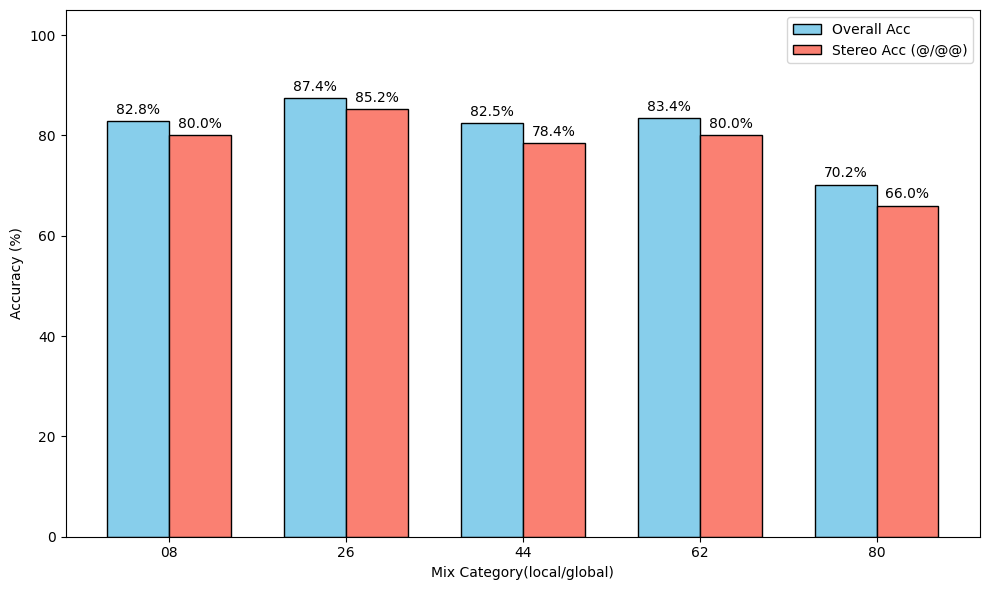

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def get_accuracies(file_path):
    if not os.path.exists(file_path):
        return None, None
    
    df = pd.read_csv(file_path)
    # 完全一致判定
    df['is_correct'] = df['answer'].astype(str) == df['predict'].astype(str)
    # 立体化学記号 '@' を含むか判定
    df['has_stereo'] = df['answer'].astype(str).str.contains('@')
    
    overall_acc = df['is_correct'].mean() * 100
    
    stereo_df = df[df['has_stereo']]
    stereo_acc = stereo_df['is_correct'].mean() * 100 if not stereo_df.empty else 0
    
    return overall_acc, stereo_acc

# データ収集
labels = ['08','26', '44', '62','80']
files =  ['mix08.csv','mix26.csv', 'mix44.csv', 'mix62.csv','mix80.csv']

overall_scores = []
stereo_scores = []

for f in files:
    ov, st = get_accuracies(f)
    overall_scores.append(ov if ov is not None else 0)
    stereo_scores.append(st if st is not None else 0)

# --- グラフ描画 ---
x = np.arange(len(labels))  # ラベルの位置
width = 0.35  # 棒の幅

fig, ax = plt.subplots(figsize=(10, 6))

# 棒グラフの描画
rects1 = ax.bar(x - width/2, overall_scores, width, label='Overall Acc', color='skyblue', edgecolor='black')
rects2 = ax.bar(x + width/2, stereo_scores, width, label='Stereo Acc (@/@@)', color='salmon', edgecolor='black')

# 軸ラベルとタイトルの設定
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Mix Category(local/global)')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 105) # 100%を少し超えるくらいで見やすく
ax.legend()

# 数値を棒の上に表示
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3ポイント上にオフセット
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import os

def analyze_stereo_concentration(file_path):
    if not os.path.exists(file_path):
        return f"{file_path}: File not found"
    
    df = pd.read_csv(file_path)
    
    # 1. 判定フラグの作成
    df['is_correct'] = df['answer'].astype(str) == df['predict'].astype(str)
    df['has_stereo'] = df['answer'].astype(str).str.contains('@')
    
    # --- 全体におけるキラルの割合 ---
    total_count = len(df)
    total_stereo_count = df['has_stereo'].sum()
    original_stereo_ratio = (total_stereo_count / total_count) * 100
    
    # --- 間違えたデータにおけるキラルの割合 ---
    error_df = df[df['is_correct'] == False]
    total_errors = len(error_df)
    
    if total_errors > 0:
        error_stereo_count = error_df['has_stereo'].sum()
        error_stereo_ratio = (error_stereo_count / total_errors) * 100
    else:
        error_stereo_count = 0
        error_stereo_ratio = 0.0

    return {
        "file": file_path,
        "original_ratio": f"{original_stereo_ratio:.2f}%",
        "error_ratio": f"{error_stereo_ratio:.2f}%",
        "total_errors": total_errors,
        "stereo_in_errors": f"{error_stereo_count}/{total_errors}"
    }

# 対象ファイル
files = ['mix08.csv','mix26.csv', 'mix44.csv', 'mix62.csv','mix80.csv']

print(f"{'File':<12} | {'Original Stereo %':<20} | {'Stereo % in Errors':<20} | {'Error Count'}")
print("-" * 75)

for f in files:
    res = analyze_stereo_concentration(f)
    if isinstance(res, dict):
        print(f"{res['file']:<12} | {res['original_ratio']:<20} | {res['error_ratio']:<20} | {res['stereo_in_errors']}")
    else:
        print(res)

File         | Original Stereo %    | Stereo % in Errors   | Error Count
---------------------------------------------------------------------------
mix08.csv    | 71.63%               | 83.33%               | 50/60
mix26.csv    | 71.63%               | 84.09%               | 37/44
mix44.csv    | 71.63%               | 88.52%               | 54/61
mix62.csv    | 71.63%               | 86.21%               | 50/58
mix80.csv    | 71.63%               | 81.73%               | 85/104


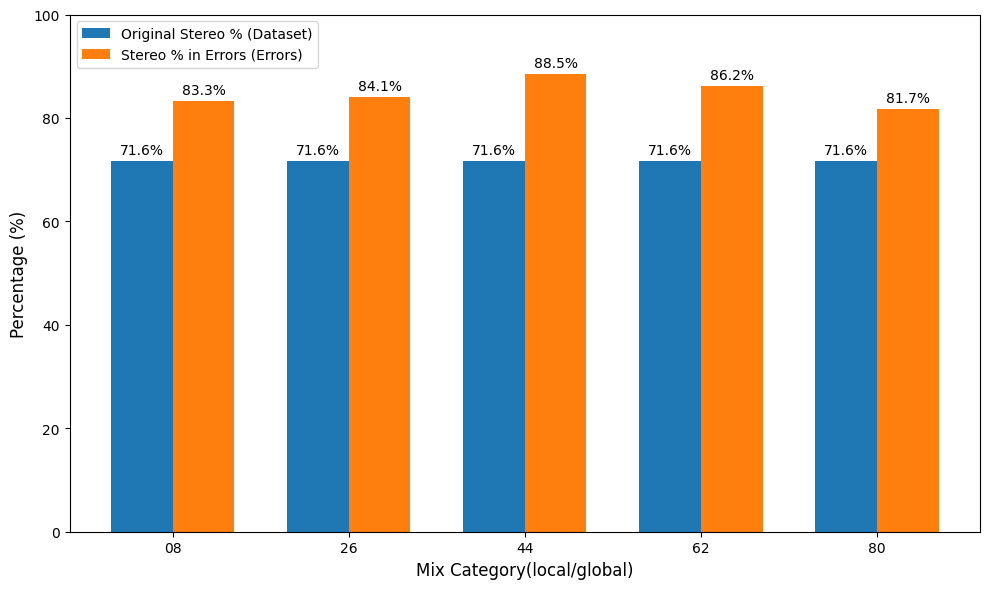

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. データの準備 ---
labels = ['08','26', '44', '62','80']

# 全データ数 349, そのうちキラル(Stereo) 250
total_n = 349
total_s = 250
original_ratio = (total_s / total_n) * 100 # 約71.63%

# ユーザー提供の正答率から、エラー数とエラー内のキラル数を算出
# mix26: Overall 87.39%, Stereo 85.20%
# mix44: Overall 82.52%, Stereo 78.40%
# mix62: Overall 83.38%, Stereo 80.00%
error_ratios_in_errors = [83.33,84.09, 88.52, 86.21,81.73] # 計算済みの割合

# --- 2. グラフ描画の設定 ---
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# 背景の元のキラル割合（グレーの斜線）
rects1 = ax.bar(x - width/2, [original_ratio] * 5, width, 
                label='Original Stereo % (Dataset)')

# 間違えた中のキラル割合（オレンジ）
rects2 = ax.bar(x + width/2, error_ratios_in_errors, width, 
                label='Stereo % in Errors (Errors)') 

# --- 3. 装飾 ---
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Mix Category(local/global)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 100)
ax.legend(loc='upper left')

# 棒の上に数値を表示する関数
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

# レイアウト調整と保存
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import os

def analyze_stereo_concentration(file_path):
    if not os.path.exists(file_path):
        return f"{file_path}: File not found"
    
    df = pd.read_csv(file_path)
    
    # 1. 判定フラグの作成
    df['is_correct'] = df['answer'].astype(str) == df['predict'].astype(str)
    df['has_stereo'] = df['answer'].astype(str).str.contains('@')
    
    # --- 全体におけるキラルの割合 ---
    total_count = len(df)
    total_stereo_count = df['has_stereo'].sum()
    original_stereo_ratio = (total_stereo_count / total_count) * 100
    
    # --- 間違えたデータにおけるキラルの割合 ---
    error_df = df[df['is_correct'] == False]
    total_errors = len(error_df)
    
    if total_errors > 0:
        error_stereo_count = error_df['has_stereo'].sum()
        error_stereo_ratio = (error_stereo_count / total_errors) * 100
    else:
        error_stereo_count = 0
        error_stereo_ratio = 0.0

    return {
        "file": file_path,
        "original_ratio": f"{original_stereo_ratio:.2f}%",
        "error_ratio": f"{error_stereo_ratio:.2f}%",
        "total_errors": total_errors,
        "stereo_in_errors": f"{error_stereo_count}/{total_errors}"
    }

# 対象ファイル
files = ['mix08_10.csv','mix26_10.csv', 'mix44_10.csv', 'mix62_10.csv','mix80_10.csv']

print(f"{'File':<12} | {'Original Stereo %':<20} | {'Stereo % in Errors':<20} | {'Error Count'}")
print("-" * 75)

for f in files:
    res = analyze_stereo_concentration(f)
    if isinstance(res, dict):
        print(f"{res['file']:<12} | {res['original_ratio']:<20} | {res['error_ratio']:<20} | {res['stereo_in_errors']}")
    else:
        print(res)

File         | Original Stereo %    | Stereo % in Errors   | Error Count
---------------------------------------------------------------------------
mix08_10.csv | 71.63%               | 83.67%               | 41/49
mix26_10.csv | 71.63%               | 82.00%               | 41/50
mix44_10.csv | 71.63%               | 82.22%               | 37/45
mix62_10.csv | 71.63%               | 92.00%               | 46/50
mix80_10.csv | 71.63%               | 80.61%               | 79/98


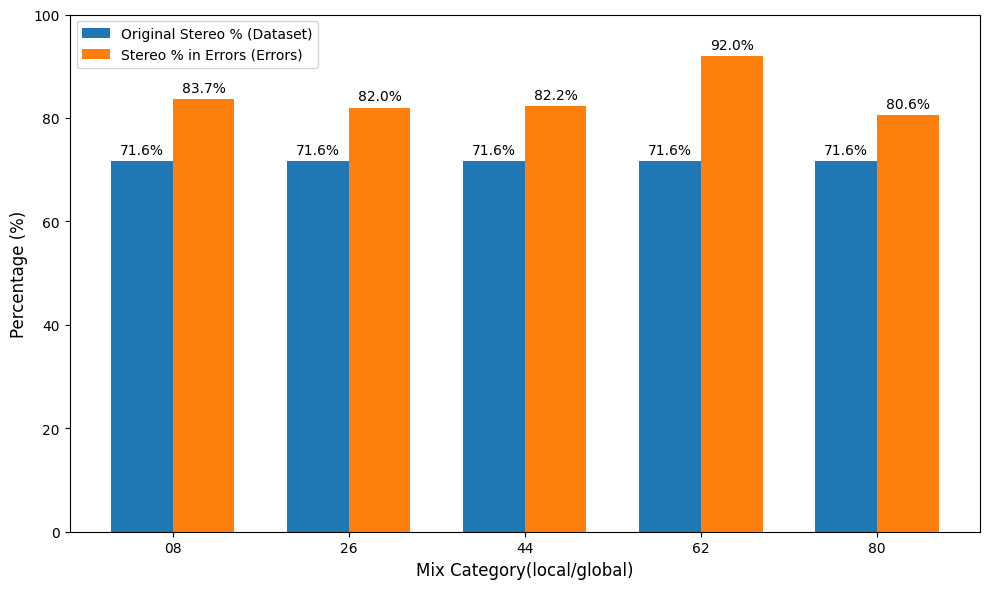

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. データの準備 ---
labels = ['08','26','44','62','80']

# 全データ数 349, そのうちキラル(Stereo) 250
total_n = 349
total_s = 250
original_ratio = (total_s / total_n) * 100 # 約71.63%

# ユーザー提供の正答率から、エラー数とエラー内のキラル数を算出
# mix26: Overall 87.39%, Stereo 85.20%
# mix44: Overall 82.52%, Stereo 78.40%
# mix62: Overall 83.38%, Stereo 80.00%
error_ratios_in_errors = [83.67,82.00,82.22,92, 80.61] # 計算済みの割合

# --- 2. グラフ描画の設定 ---
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# 背景の元のキラル割合（グレーの斜線）
rects1 = ax.bar(x - width/2, [original_ratio] * 5, width, 
                label='Original Stereo % (Dataset)')

# 間違えた中のキラル割合（オレンジ）
rects2 = ax.bar(x + width/2, error_ratios_in_errors, width, 
                label='Stereo % in Errors (Errors)') 

# --- 3. 装飾 ---
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Mix Category(local/global)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 100)
ax.legend(loc='upper left')

# 棒の上に数値を表示する関数
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

# レイアウト調整と保存
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import os

def analyze_smiles_accuracy(file_path):
    if not os.path.exists(file_path):
        return f"{file_path}: File not found"
    
    # CSV読み込み
    df = pd.read_csv(file_path)
    
    # 1. 全体の完全一致（True/False）を判定
    # 文字列として比較するため、念のためstr型に変換
    df['is_correct'] = df['answer'].astype(str) == df['predict'].astype(str)
    
    # 2. '@' または '@@' を含む行を特定
    # SMILESにおいて立体化学を示す記号が含まれているか
    df['has_stereo'] = df['answer'].astype(str).str.contains('@')
    
    # --- 集計 ---
    # 全体の正答率
    overall_acc = df['is_correct'].mean() * 100
    
    # 立体化学を含む行だけのデータ
    stereo_df = df[df['has_stereo']]
    if not stereo_df.empty:
        stereo_acc = stereo_df['is_correct'].mean() * 100
        stereo_count = len(stereo_df)
    else:
        stereo_acc = 0.0
        stereo_count = 0

    return {
        "file": file_path,
        "overall_accuracy": f"{overall_acc:.2f}%",
        "stereo_only_accuracy": f"{stereo_acc:.2f}%",
        "stereo_sample_count": stereo_count,
        "total_sample_count": len(df)
    }

# 対象ファイル
files = ['mix08_10.csv','mix26_10.csv', 'mix44_10.csv', 'mix62_10.csv','mix80_10.csv']

print(f"{'File':<12} | {'Overall Acc':<12} | {'Stereo Acc':<12} | {'Stereo Count'}")
print("-" * 60)

for f in files:
    result = analyze_smiles_accuracy(f)
    if isinstance(result, dict):
        print(f"{result['file']:<12} | {result['overall_accuracy']:<12} | {result['stereo_only_accuracy']:<12} | {result['stereo_sample_count']}/{result['total_sample_count']}")
    else:
        print(result)

File         | Overall Acc  | Stereo Acc   | Stereo Count
------------------------------------------------------------
mix08_10.csv | 85.96%       | 83.60%       | 250/349
mix26_10.csv | 85.67%       | 83.60%       | 250/349
mix44_10.csv | 87.11%       | 85.20%       | 250/349
mix62_10.csv | 85.67%       | 81.60%       | 250/349
mix80_10.csv | 71.92%       | 68.40%       | 250/349


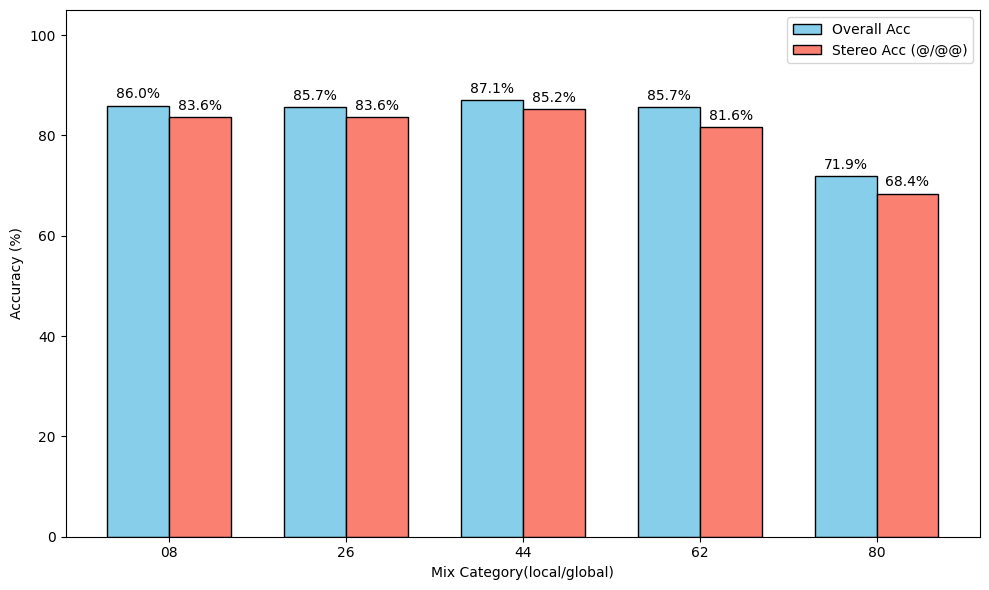

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def get_accuracies(file_path):
    if not os.path.exists(file_path):
        return None, None
    
    df = pd.read_csv(file_path)
    # 完全一致判定
    df['is_correct'] = df['answer'].astype(str) == df['predict'].astype(str)
    # 立体化学記号 '@' を含むか判定
    df['has_stereo'] = df['answer'].astype(str).str.contains('@')
    
    overall_acc = df['is_correct'].mean() * 100
    
    stereo_df = df[df['has_stereo']]
    stereo_acc = stereo_df['is_correct'].mean() * 100 if not stereo_df.empty else 0
    
    return overall_acc, stereo_acc

# データ収集
labels = ['08','26','44','62','80']

files = ['mix08_10.csv','mix26_10.csv', 'mix44_10.csv', 'mix62_10.csv','mix80_10.csv']

overall_scores = []
stereo_scores = []

for f in files:
    ov, st = get_accuracies(f)
    overall_scores.append(ov if ov is not None else 0)
    stereo_scores.append(st if st is not None else 0)

# --- グラフ描画 ---
x = np.arange(len(labels))  # ラベルの位置
width = 0.35  # 棒の幅

fig, ax = plt.subplots(figsize=(10, 6))

# 棒グラフの描画
rects1 = ax.bar(x - width/2, overall_scores, width, label='Overall Acc', color='skyblue', edgecolor='black')
rects2 = ax.bar(x + width/2, stereo_scores, width, label='Stereo Acc (@/@@)', color='salmon', edgecolor='black')

# 軸ラベルとタイトルの設定
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Mix Category(local/global)')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 105) # 100%を少し超えるくらいで見やすく
ax.legend()

# 数値を棒の上に表示
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3ポイント上にオフセット
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()